In [ ]:
"""
MILK10k — Exploratory Data Analysis (Session 1 homework)

Run this top to bottom in VS Code (with the Jupyter extension, using the
'# %%' cell markers), in Jupyter, or in Google Colab.

BEFORE RUNNING: download and unzip the dataset so you end up with a
'milk10k/' folder containing 'metadata.csv', 'images/', and
'supplements/training_gt.csv'.

  - In Google Colab, run this in a cell:
      !wget https://isic-archive.s3.amazonaws.com/dois/10.34970-648456/milk10k.zip
      !unzip milk10k.zip -d milk10k

  - Locally (Mac/Linux terminal), you can run the same two commands
    (drop the leading '!'), or download the .zip in your browser from
    https://api.isic-archive.com/doi/milk10k/ and unzip it into this
    project's data/ folder.
"""

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [4]:
from pathlib import Path
list(Path("..").rglob("metadata.csv"))

[]

In [6]:
from pathlib import Path
p = Path.home() / "milk10k-cv-course"
for item in p.rglob("*"):
    print(item)

C:\Users\krisi\milk10k-cv-course\.git
C:\Users\krisi\milk10k-cv-course\.gitignore
C:\Users\krisi\milk10k-cv-course\data
C:\Users\krisi\milk10k-cv-course\notebooks
C:\Users\krisi\milk10k-cv-course\README.md
C:\Users\krisi\milk10k-cv-course\requirements.txt
C:\Users\krisi\milk10k-cv-course\src
C:\Users\krisi\milk10k-cv-course\.git\config
C:\Users\krisi\milk10k-cv-course\.git\description
C:\Users\krisi\milk10k-cv-course\.git\fsmonitor--daemon
C:\Users\krisi\milk10k-cv-course\.git\HEAD
C:\Users\krisi\milk10k-cv-course\.git\hooks
C:\Users\krisi\milk10k-cv-course\.git\index
C:\Users\krisi\milk10k-cv-course\.git\info
C:\Users\krisi\milk10k-cv-course\.git\logs
C:\Users\krisi\milk10k-cv-course\.git\objects
C:\Users\krisi\milk10k-cv-course\.git\packed-refs
C:\Users\krisi\milk10k-cv-course\.git\refs
C:\Users\krisi\milk10k-cv-course\.git\fsmonitor--daemon\cookies
C:\Users\krisi\milk10k-cv-course\.git\hooks\applypatch-msg.sample
C:\Users\krisi\milk10k-cv-course\.git\hooks\commit-msg.sample
C:\Users

In [7]:
from pathlib import Path
DATA_DIR = Path("../data/milk10k")

print("metadata.csv exists:", (DATA_DIR / "metadata.csv").exists())
print("training_gt.csv exists:", (DATA_DIR / "supplements" / "training_gt.csv").exists())
print("images folder exists:", (DATA_DIR / "images").exists())

if (DATA_DIR / "supplements").exists():
    print("\nFiles in supplements/:")
    for f in (DATA_DIR / "supplements").iterdir():
        print(" -", f.name)

metadata.csv exists: True
training_gt.csv exists: True
images folder exists: True

Files in supplements/:
 - training_gt.csv
 - training_input.csv
 - training_supp.csv


In [2]:
# Point this at wherever you unzipped the dataset.
DATA_DIR = Path("../data/milk10k")   # e.g. project/data/milk10k
IMG_DIR = DATA_DIR / "images"

In [8]:
# metadata.csv  -> one row PER IMAGE
# training_gt.csv -> one row PER LESION (one-hot columns for the 11 classes)
df = pd.read_csv(DATA_DIR / "metadata.csv")
gt = pd.read_csv(DATA_DIR / "supplements" / "training_gt.csv")

print("metadata.csv shape:", df.shape)
print("training_gt.csv shape:", gt.shape)
print(df["lesion_id"].nunique(), "unique lesions")

metadata.csv shape: (10480, 17)
training_gt.csv shape: (5240, 12)
5240 unique lesions


In [9]:
print("\nCoarse diagnosis counts:")
print(df["diagnosis_1"].value_counts())

print("\nMissing values (fraction) in key columns:")
print(df[["age_approx", "sex", "anatom_site_general"]].isna().mean())

# Confirm the 2-images-per-lesion structure mentioned in class
print("\nEvery lesion has exactly 2 images:",
      (df.groupby("lesion_id").size() == 2).all())


Coarse diagnosis counts:
diagnosis_1
Malignant        7268
Benign           2966
Indeterminate     246
Name: count, dtype: int64

Missing values (fraction) in key columns:
age_approx             0.003817
sex                    0.000000
anatom_site_general    0.373282
dtype: float64

Every lesion has exactly 2 images: True


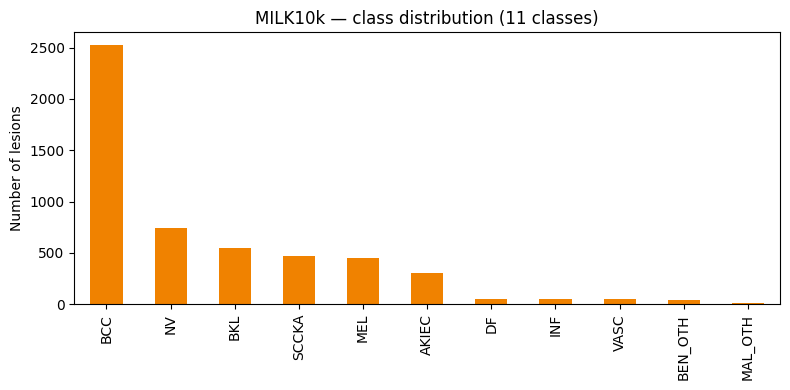

In [10]:
counts = gt.drop(columns="lesion_id").sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
counts.plot(kind="bar", ax=ax, color="#F08200")
ax.set_ylabel("Number of lesions")
ax.set_title("MILK10k — class distribution (11 classes)")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

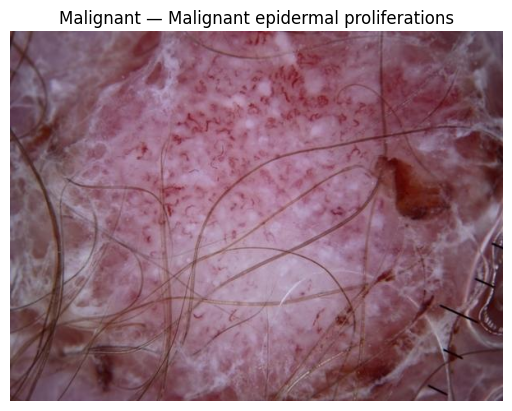

In [11]:
row = df.iloc[0]
img_path = IMG_DIR / f'{row["isic_id"]}.jpg'
img = Image.open(img_path).convert("RGB")

plt.imshow(img)
sub_label = row["diagnosis_2"] if pd.notna(row["diagnosis_2"]) else ""
plt.title(f'{row["diagnosis_1"]} — {sub_label}')
plt.axis("off")
plt.show()

In [12]:
arr = np.array(img)
print("shape:", arr.shape)     # (height, width, channels)
print("dtype:", arr.dtype)     # usually uint8
print("min / max pixel value:", arr.min(), arr.max())

shape: (450, 600, 3)
dtype: uint8
min / max pixel value: 0 230


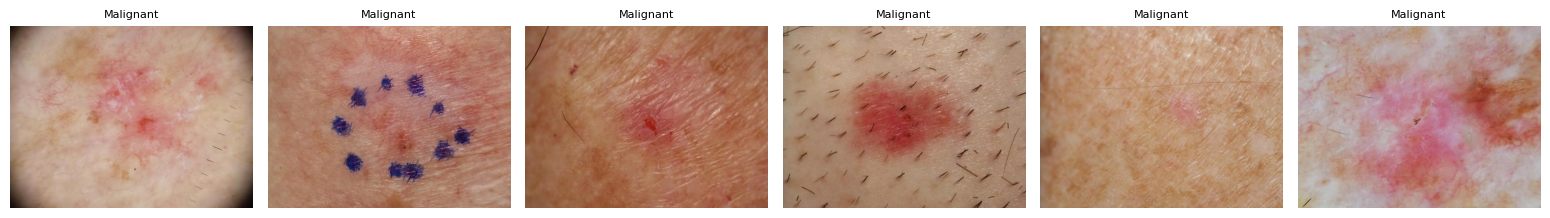

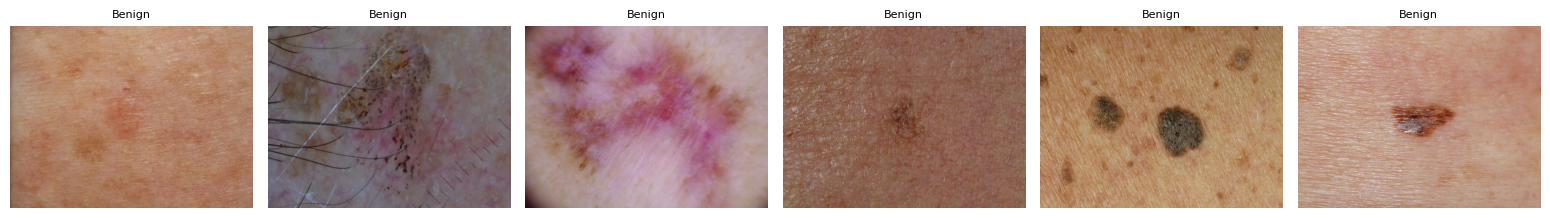

In [13]:
def show_samples(df, img_dir, n=6, diagnosis=None, seed=0):
    """Show n random sample images, optionally filtered by diagnosis_1."""
    subset = df if diagnosis is None else df[df["diagnosis_1"] == diagnosis]
    sample = subset.sample(n=n, random_state=seed)
    fig, axes = plt.subplots(1, n, figsize=(2.6 * n, 3))
    for ax, (_, r) in zip(axes, sample.iterrows()):
        im = Image.open(img_dir / f'{r["isic_id"]}.jpg')
        ax.imshow(im)
        ax.set_title(r["diagnosis_1"], fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(df, IMG_DIR, n=6, diagnosis="Malignant")
show_samples(df, IMG_DIR, n=6, diagnosis="Benign")

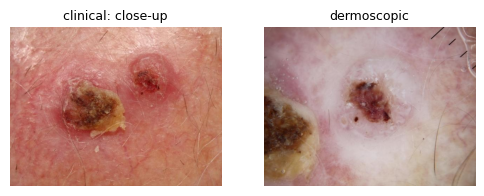

In [14]:
# Each lesion has ONE dermoscopic image and ONE clinical close-up.
# This is why any train/val/test split must group by lesion_id.
lesion = df["lesion_id"].value_counts().index[0]
pair = df[df["lesion_id"] == lesion]

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for ax, (_, r) in zip(axes, pair.iterrows()):
    im = Image.open(IMG_DIR / f'{r["isic_id"]}.jpg')
    ax.imshow(im)
    ax.set_title(r["image_type"], fontsize=9)
    ax.axis("off")
plt.show()

In [15]:
widths, heights = [], []
for _, r in df.sample(200, random_state=0).iterrows():
    with Image.open(IMG_DIR / f'{r["isic_id"]}.jpg') as im:
        w, h = im.size
    widths.append(w)
    heights.append(h)

print("avg width:", np.mean(widths))
print("avg height:", np.mean(heights))

avg width: 600.0
avg height: 450.0


In [16]:
print("\n--- EDA SUMMARY ---")
print(f"Total images: {len(df)}")
print(f"Total unique lesions: {df['lesion_id'].nunique()}")
print(f"Coarse diagnosis breakdown:\n{df['diagnosis_1'].value_counts()}")
print(f"Most common fine-grained class: {counts.idxmax()} ({counts.max()} lesions)")
print(f"Rarest fine-grained class: {counts.idxmin()} ({counts.min()} lesions)")


--- EDA SUMMARY ---
Total images: 10480
Total unique lesions: 5240
Coarse diagnosis breakdown:
diagnosis_1
Malignant        7268
Benign           2966
Indeterminate     246
Name: count, dtype: int64
Most common fine-grained class: BCC (2522 lesions)
Rarest fine-grained class: MAL_OTH (9 lesions)
